# Анализ результатов A/B-тестирования новой версии сайта интернет-магазина
Автор: Ельцова Анастасия

---
## Описание проекта

Нужно проанализировать другие данные интернет-магазина, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Задача — провести оценку результатов A/B-теста. В нашем распоряжении:
* данные о действиях пользователей и распределении их на группы
* техническое задание

Оценить корректность проведения теста и проанализировать его результаты.

## Цели исследования

Оценить, привело ли внедрение упрощенной версии сайта к статистически значимому увеличению доли пользователей, совершающих покупку (конверсии).

Для этого будет проведена проверка гипотезы:
* Нулевая гипотеза $H_0:$ <br> Конверсия пользователей в покупателей в группе с упрощенной версией сайта не больше или равна конверсии в группе со старой версией сайта.
* Альтернативная гипотеза $H_1:$ <br> Конверсия пользователей в покупателей в группе с упрощенной версией сайта больше конверсии в группе со старой версией сайта, и это различие статистически значимо.

---

## Содержимое проекта

1. Загрузка данных и оценка их целостности
2. Оценка корректности проведения теста
3. Оценка результатов A/B-тестирования
4. Выводы по результатам A/B-тестирования

---

## 1. Загрузка данных и оценка их целостности

---

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [2]:
participants = pd.read_csv(
    "https://code._____.csv"
)
events = pd.read_csv(
    "https://code._____.zip",
    parse_dates=["event_dt"],
    low_memory=False,
)

In [3]:
display(participants.head(), participants.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


None

In [4]:
# Проверяем датасет на явные дубликаты
duplicate_count = participants.duplicated().sum()

if duplicate_count == 0:
    print("Явных дубликатов не обнаружено")
else:
    print(f"Обнаружены явные дубликаты: {duplicate_count} шт.")

Явных дубликатов не обнаружено


---
Датасет `participants` содержит 4 столбца и 14525 строк. Данные соответствуют верному типу, пропуски и дубликаты строк отсутствуют. Значения в столбцах соответствуют своему описанию.

---

In [5]:
display(events.head(), events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


None

In [6]:
# Выводим количество пропущенных строк  в каждом столбце в абсолютных и относительных значениях
missing_percentage = round(events.isna().sum() / len(events) * 100, 2)
missing_df = pd.DataFrame(
    {
        "Количество пропусков": events.isna().sum(),
        "Доля пропущенных значений": events.isna().mean(),
        "Процент пропусков (%)": missing_percentage,
    }
)
print("\nАнализ пропущенных значений:")
display(missing_df)


Анализ пропущенных значений:


,Количество пропусков,Доля пропущенных значений,Процент пропусков (%)
user_id,0,0.000000,0.00
event_dt,0,0.000000,0.00
event_name,0,0.000000,0.00
details,538264,0.683696,68.37


In [7]:
# Проверяем датасет на явные дубликаты
duplicate_count = events.duplicated().sum()

if duplicate_count == 0:
    print("Явных дубликатов не обнаружено")
else:
    print(f"Обнаружены явные дубликаты: {duplicate_count} шт.")

if duplicate_count > 0:
    print(f"Процент дубликатов: {duplicate_count/len(events)*100:.2f}%")

Обнаружены явные дубликаты: 36318 шт.
Процент дубликатов: 4.61%


In [8]:
# Удаляем дубликаты
events = events.drop_duplicates()
duplicate_count = events.duplicated().sum()
duplicate_count

0

---
Датасет `events` содержит 4 столбца и 787286 строк. Содержит данные строкового и временного типов. Пропуски присутствуют в столбце `details`(68.37%) - не удаляем, так как это особенность данных. Обнаружено 36318 дубликатов (4.61% от всех данных) - удалены. Значения в столбцах соответствуют своему описанию.

---

## 2. Оценка корректности проведения теста

**Оценим корректность проведения теста по таблице `ab_test_participants`.**

Выделим пользователей, участвующих в тесте, и проверим:
- соответствие требованиям технического задания
- равномерность распределения пользователей по группам теста
- отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

---

In [9]:
# Посмотрим, какие группы и тесты встречаются в эксперименте
display(participants["group"].unique(), participants["ab_test"].unique())

array(['B', 'A'], dtype=object)

array(['interface_eu_test', 'recommender_system_test'], dtype=object)

---
Видим, что в эксперименте две группы (А и В) и два теста.

Проверим нет ли пользователей, которые участвуют в двух тестовых группах одновременно.

---

In [10]:
# Выделим пользователей, участвующих тесте interface_eu_test
interface_eu_test = participants[participants["ab_test"] == "interface_eu_test"]

# Выделим пользователей группы В, участвующих в конкурирующем тесте recommender_system_test
recommender_system_test_B = participants[
    (participants["ab_test"] == "recommender_system_test")
    & (participants["group"] == "B")
]

# Найдем пользователей, которые находятся в группе B нашего теста и одновременно участвуют в конкурирующем тесте
intersection = interface_eu_test[
    (interface_eu_test["group"] == "B")
    & (interface_eu_test["user_id"].isin(recommender_system_test_B["user_id"]))
]
print(f"Количество пересечений пользователей в контрольной группе: {len(intersection)}")

Количество пересечений пользователей в контрольной группе: 116


---
Найдено 116 записей, которые попали в две тестовые группы одновременно. Удалим их.

---

In [11]:
# Удалим этих пользователей из нашего теста
interface_eu_test = interface_eu_test[
    ~interface_eu_test["user_id"].isin(intersection["user_id"])
]
interface_eu_test.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
2,001064FEAAB631A1,A,interface_eu_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android


---
Посчитаем количество уникальных пользователей в каждой группе.

---

In [12]:
# Рассчитаем количество уникальных пользователей в каждой группе
group_A = interface_eu_test[interface_eu_test["group"] == "A"]["user_id"].nunique()
group_B = interface_eu_test[interface_eu_test["group"] == "B"]["user_id"].nunique()
print(
    f"Количество уникальных пользователей в группе А = {group_A}.\nКоличество уникальных пользователей в группе B =  {group_B}."
)

Количество уникальных пользователей в группе А = 5383.
Количество уникальных пользователей в группе B =  5351.


In [13]:
# Посмотрим, в каком процентном соотношении находятся группы
round(
    100
    * interface_eu_test[interface_eu_test["group"] == "A"]["user_id"].nunique()
    / interface_eu_test["user_id"].nunique(),
    2,
), round(
    100
    * interface_eu_test[interface_eu_test["group"] == "B"]["user_id"].nunique()
    / interface_eu_test["user_id"].nunique(),
    2,
)

(50.15, 49.85)

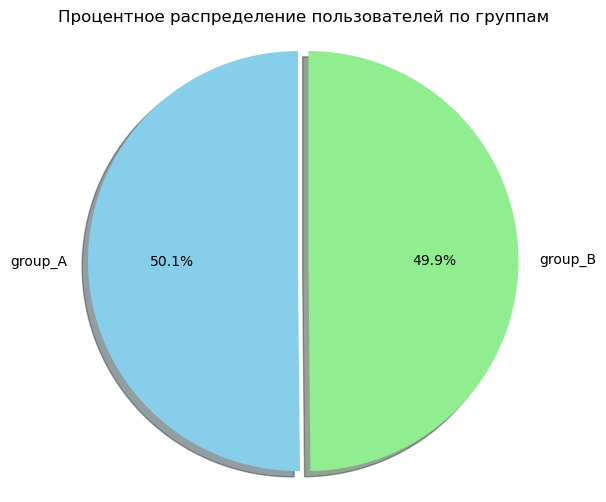

In [14]:
# Построим визуализацию, на которой будет видно возможное различие двух групп
group_counts = interface_eu_test.groupby("group")["user_id"].nunique()
groups = ["group_" + group for group in group_counts.index.tolist()]
users = group_counts.values.tolist()

plt.figure(figsize=(6, 6))
colors = ["skyblue", "lightgreen"]
explode = (0.05, 0)

plt.pie(
    users,
    labels=groups,
    autopct="%1.1f%%",
    colors=colors,
    explode=explode,
    startangle=90,
    shadow=True,
)
plt.title("Процентное распределение пользователей по группам")
plt.axis("equal")
plt.show()

In [15]:
# Посчитаем количество уникальных групп на каждого пользователя
interface_eu_test.groupby("user_id", as_index=False)["group"].nunique().sort_values(
    by="group", ascending=False
)

,user_id,group
0,0002CE61FF2C4011,1
7149,AA60EFB0038DA8BA,1
7151,AA6E3382835E430B,1
7152,AA734F805C898448,1
7153,AA750EC1FEF2FD88,1
...,...,...
3579,558F429A7AA34D3B,1
3580,5595B31EA5FDC8B6,1
3581,559B55365A80B1F2,1
3582,55A2929C0942C754,1


---
Группы разделены практически 50/50. Аномалий нет - каждый пользователь попал только в одну группу.

Так же проверим равномерность распределения пользователей в группах по устройствам.

---

In [16]:
# Считаем долю каждого типа устройства для пользователей из группы А
device_ratio_a = (
    interface_eu_test[interface_eu_test["group"] == "A"]
    .groupby("device")["user_id"]
    .nunique()
    .reset_index(name="unique_users")
)
total_a = device_ratio_a["unique_users"].sum()
device_ratio_a["percentage"] = round(
    (device_ratio_a["unique_users"] / total_a) * 100, 2
)
device_ratio_a = device_ratio_a.sort_values("percentage", ascending=False).reset_index(
    drop=True
)
print(
    f"Общее количество пользователей в группе А: {total_a}\n\nДолевое распределение пользователей по типам устройств в группе А \n\n{device_ratio_a}"
)

# Считаем долю каждого типа устройства для пользователей из группы B
device_ratio_b = (
    interface_eu_test[interface_eu_test["group"] == "B"]
    .groupby("device")["user_id"]
    .nunique()
    .reset_index(name="unique_users")
)
total_b = device_ratio_b["unique_users"].sum()
device_ratio_b["percentage"] = round(
    (device_ratio_b["unique_users"] / total_b) * 100, 2
)
device_ratio_b = device_ratio_b.sort_values("percentage", ascending=False).reset_index(
    drop=True
)
print(
    f"Общее количество пользователей в группе B: {total_b}\n\nДолевое распределение пользователей по типам устройств в группе B \n\n{device_ratio_b}"
)

Общее количество пользователей в группе А: 5383

Долевое распределение пользователей по типам устройств в группе А 

    device  unique_users  percentage
0  Android          2445       45.42
1       PC          1346       25.00
2   iPhone          1026       19.06
3      Mac           566       10.51
Общее количество пользователей в группе B: 5351

Долевое распределение пользователей по типам устройств в группе B 

    device  unique_users  percentage
0  Android          2363       44.16
1       PC          1391       26.00
2   iPhone          1052       19.66
3      Mac           545       10.19


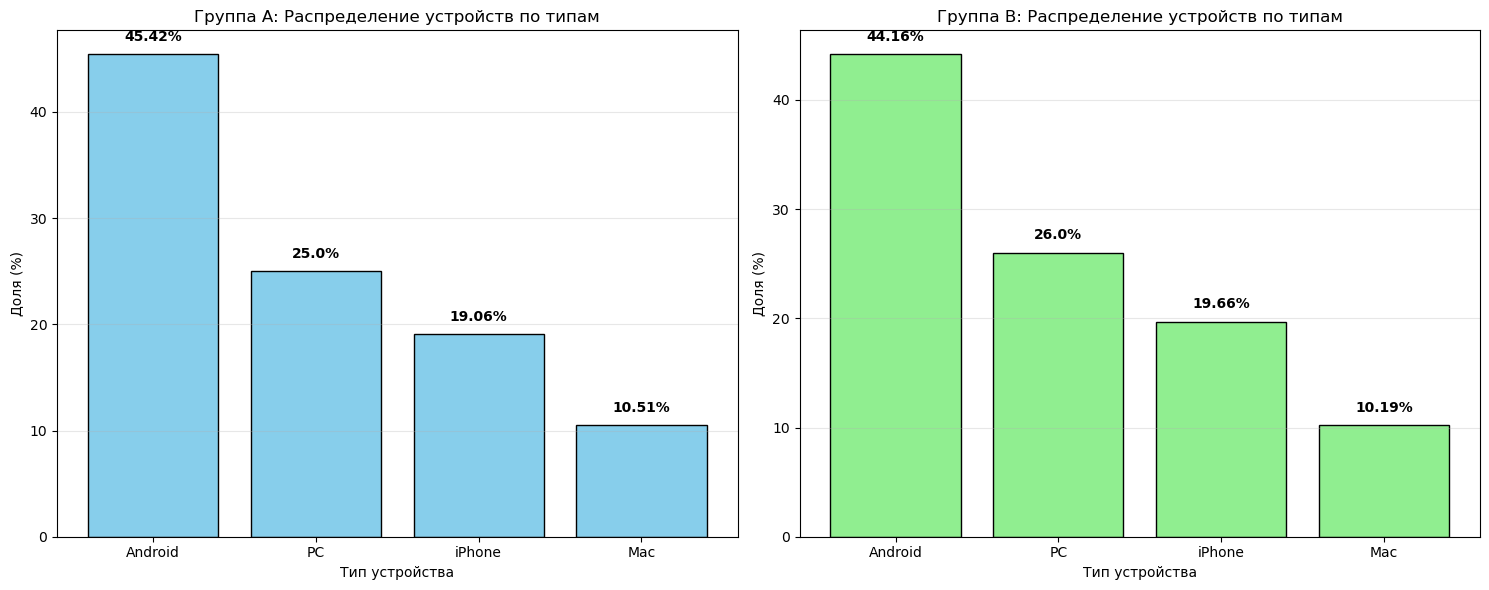

In [17]:
# Создаем фигуру с двумя subplots рядом
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Первый график - группа A
bars1 = ax1.bar(
    device_ratio_a["device"],
    device_ratio_a["percentage"],
    edgecolor="black",
    color="skyblue",
)
ax1.set_xlabel("Тип устройства")
ax1.set_ylabel("Доля (%)")
ax1.set_title("Группа A: Распределение устройств по типам")
ax1.grid(axis="y", alpha=0.3)

# Добавляем значения на столбцы для группы A
for bar, percentage in zip(bars1, device_ratio_a["percentage"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{percentage}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Второй график - группа B
bars2 = ax2.bar(
    device_ratio_b["device"],
    device_ratio_b["percentage"],
    edgecolor="black",
    color="lightgreen",
)
ax2.set_xlabel("Тип устройства")
ax2.set_ylabel("Доля (%)")
ax2.set_title("Группа B: Распределение устройств по типам")
ax2.grid(axis="y", alpha=0.3)

# Добавляем значения на столбцы для группы B
for bar, percentage in zip(bars2, device_ratio_b["percentage"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{percentage}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

---
Распределение данных в группах демонстрируют хорошую сбалансированность по типам устройств с незначительными различиями, которые вряд ли окажут существенное влияние на результаты A/B-теста. Репрезентативность сохранена - группы отражают схожую структуру пользователей. Можно проводить анализ без статистической коррекции.

---

**Проанализируем данные о пользовательской активности по таблице `ab_test_events`.**

Оставим только события, связанные с участвующими в изучаемом тесте пользователями.

---

In [18]:
# Получаем список user_id из датасета interface_eu_test
test_user_ids = interface_eu_test["user_id"].unique()

# Фильтруем события только для этих пользователей
events_filtered = events[events["user_id"].isin(test_user_ids)]

print(f"Событий в изучаемом тесте: {len(events_filtered)}")
print(events_filtered.head(), events_filtered.info())

Событий в изучаемом тесте: 72935
<class 'pandas.core.frame.DataFrame'>
Index: 72935 entries, 64672 to 780371
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     72935 non-null  object        
 1   event_dt    72935 non-null  datetime64[ns]
 2   event_name  72935 non-null  object        
 3   details     20261 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 2.8+ MB
                user_id            event_dt    event_name details
64672  5F506CEBEDC05D30 2020-12-06 14:10:01  registration     0.0
64946  51278A006E918D97 2020-12-06 14:37:25  registration    -3.8
66585  A0C1E8EFAD874D8B 2020-12-06 17:20:22  registration   -3.32
67873  275A8D6254ACF530 2020-12-06 19:36:54  registration   -0.48
67930  0B704EB2DC7FCA4B 2020-12-06 19:42:20  registration     0.0 None


---
Определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации.

---

In [19]:
# Находим даты регистрации
registration_dates = (
    events_filtered[events_filtered["event_name"] == "registration"]
    .groupby("user_id")["event_dt"]
    .min()
    .reset_index()
    .rename(columns={"event_dt": "reg_date"})
)

# Объединяем с основным датасетом
events_filtered = events_filtered.merge(registration_dates, on="user_id", how="left")

In [20]:
# Вычисляем разницу в днях
events_filtered["days_after_reg"] = (
    events_filtered["event_dt"] - events_filtered["reg_date"]
).dt.days

# Фильтруем первые 7 дней
events_first_7_days = events_filtered[
    (events_filtered["days_after_reg"] >= 0) & (events_filtered["days_after_reg"] <= 6)
]
print(
    f"Количество событий в первые 7 дней с момента регистрации: {len(events_first_7_days)}"
)

Количество событий в первые 7 дней с момента регистрации: 62934


---
**Оценим достаточность выборки для получения статистически значимых результатов A/B-теста.**

Заданные параметры:
- базовый показатель конверсии — 30%
- мощность теста — 80%
- достоверность теста — 95%
- ожидаемый прирост составляет 3 п.п.

---
Гипотеза из ТЗ заключается в следующем: упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.

Рассчитаем необходимое для данного эксперимента количество пользователей, чтобы оценить достаточнойсть выборки. Для этого воспользуемся он-лайн калькурятором Эвана Миллера (`https://www.evanmiller.org/ab-testing/sample-size.html`).

Необходимый размер выборки для каждой группы: 3692

---
Количество уникальных пользователей в группе А = 5383, в группе B =  5351. Выборка достаточна для получения статистически значимых результатов A/B-теста.

---

Рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

---

In [21]:
# Проверим данные за 7 дней на наличие дубликатов
duplicate_events = events_first_7_days.duplicated().sum()

if duplicate_events == 0:
    print("Явных дубликатов не обнаружено")
else:
    print(f"Обнаружены явные дубликаты: {duplicate_events} шт.")

if duplicate_count > 0:
    print(f"Процент дубликатов: {duplicate_count/len(events)*100:.2f}%")

Явных дубликатов не обнаружено


In [22]:
# Проверим данные за 7 дней на наличие пропусков
missing_perc = round(
    events_first_7_days.isna().sum() / len(events_first_7_days) * 100, 2
)
missing_events = pd.DataFrame(
    {
        "Количество пропусков": events_first_7_days.isna().sum(),
        "Доля пропущенных значений": events_first_7_days.isna().mean(),
        "Процент пропусков (%)": missing_perc,
    }
)
print("\nАнализ пропущенных значений:")
display(missing_events)


Анализ пропущенных значений:


,Количество пропусков,Доля пропущенных значений,Процент пропусков (%)
user_id,0,0.000000,0.00
event_dt,0,0.000000,0.00
event_name,0,0.000000,0.00
details,45965,0.730368,73.04
reg_date,0,0.000000,0.00
days_after_reg,0,0.000000,0.00


---
Дубликатов не обнаружено, пропуски содержатся только в столбце с дополнительными данными о событии.

---

In [23]:
# Рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.
events_first_7_days

,user_id,event_dt,event_name,details,reg_date,days_after_reg
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25,0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22,0
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54,0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20,0
...,...,...,...,...,...,...
72784,E89AF4EFC757D283,2020-12-29 21:46:43,product_cart,NaN,2020-12-23 09:35:48,6
72787,E89AF4EFC757D283,2020-12-29 21:47:56,product_cart,NaN,2020-12-23 09:35:48,6
72853,A6AFDC94A0D3B23D,2020-12-29 22:47:00,product_page,NaN,2020-12-23 13:53:33,6
72857,A6AFDC94A0D3B23D,2020-12-29 22:48:46,product_page,NaN,2020-12-23 13:53:33,6


In [24]:
# Объединяем события за 7 дней с информацией о группах
events_with_groups = events_first_7_days.merge(
    interface_eu_test[["user_id", "group"]], on="user_id", how="left"
)

# Создаем сводную таблицу для регистраций и покупок
conversion_pivot = events_with_groups[
    events_with_groups["event_name"].isin(["registration", "purchase"])
].pivot_table(index="group", columns="event_name", values="user_id", aggfunc="nunique")

# Переименовываем колонки для удобства
conversion_pivot = conversion_pivot.rename(
    columns={"registration": "total_users", "purchase": "buyers"}
)

# Рассчитываем конверсию
conversion_pivot["conversion_rate"] = (
    100 * conversion_pivot["buyers"] / conversion_pivot["total_users"]
).round(2)

print("Сводная таблица конверсии:")
print(conversion_pivot)
print()

# Рассчитываем прирост конверсии
conversion_a = conversion_pivot.loc["A", "conversion_rate"]
conversion_b = conversion_pivot.loc["B", "conversion_rate"]
conversion_diff = round(conversion_b - conversion_a, 2)

print(f"Конверсия в группе A: {conversion_a}%")
print(f"Конверсия в группе B: {conversion_b}%")
print(f"Прирост конверсии в группе B: {conversion_diff} п.п.")

Сводная таблица конверсии:
event_name  buyers  total_users  conversion_rate
group                                           
A             1480         5383            27.49
B             1579         5351            29.51

Конверсия в группе A: 27.49%
Конверсия в группе B: 29.51%
Прирост конверсии в группе B: 2.02 п.п.


---
**Предварительный вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.**

Конверсия в тестовой группе B составила 29.51% против 27.49% в контрольной группе A, что показывает абсолютный прирост на 2.02 процентных пункта. Изменение дало положительный эффект, но не достигло целевого показателя (+3 п.п.).

---

## 3. Оценка результатов A/B-тестирования

**Проверим изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.**

Используем z-test, так как необходимо проверить долевой показатель (конверсию).

Уровень значимость установим стандартный - 0.05

Формируем нулевую и альтернативную гипотезу:
* Нулевая гипотеза $H_0: \mu_{\text{А}} = \mu_{\text{В}}$ <br> Конверсия в покупку в группе с упрощенной версией сайта меньше или равна конверсии в группе со старой версией сайта.
* Альтернативная гипотеза $H_1: \mu_{\text{A}} < \mu_{\text{B}}$ <br> Конверсия в покупку в группе с упрощенной версией сайта больше конверсии в группе со старой версией сайта, и это различие статистически значимо.

---

Подготовим данные для расчётов. Подсчитаем следующие показатели:
* Число пользователей, которые совершили покупку в течение 7 дней в группе А
* Общее число пользователей в группе А
* Число пользователей, которые совершили покупку в течение 7 дней в группе В
* Общее число пользователей в группе В

In [25]:
# Считаем общее число пользователей в группах А и В
n_1, n_2 = conversion_pivot["total_users"].values
# Считаем число пользователей в группах А и В, которые совершили покупку
m_1, m_2 = conversion_pivot["buyers"].values

alpha = 0.05
# Применяем z-тест
stat_ztest, p_value_ztest = proportions_ztest(
    [m_2, m_1], [n_2, n_1], alternative="larger"
)
if p_value_ztest > alpha:
    print(f"p_value = {round(p_value_ztest, 4)} > {alpha}")
    print(
        "Нулевая гипотеза находит подтверждение. Нет статистически значимых доказательств того, что конверсия в группе B выше."
    )
else:
    print(f"p_value = {round(p_value_ztest, 4)} < {alpha}")
    print(
        "Нулевая гипотеза не находит подтверждение. Есть статистически значимые доказательства того, что конверсия в группе B выше."
    )

p_value = 0.0104 < 0.05
Нулевая гипотеза не находит подтверждение. Есть статистически значимые доказательства того, что конверсия в группе B выше.


---
## 4. Выводы по результатам A/B-тестирования

**Результаты статистического тестирования**: p-value = 0.0104 < уровня значимости α = 0.05. Нулевая гипотеза не находит подтверждение - упрощение интерфейса оказало влияние на конверсию.

Несмотря на то, что изменение интерфейса повлияло на конверсию, целевой показатель в три процентных пункта не был достигнут, фактический прирост 2.02 п.п.- эффект недостаточен для достижения бизнес-цели. Изменения работают в нужном направлении, но слабее ожидаемого

Рекомендации:
* Не внедрять текущую версию изменений, так как целевой показатель не достигнут
* Провести дополнительный анализ для понимания причин недостаточного эффекта
* Доработать интерфейс на основе полученных данных и провести новый A/B-тест
* Рассмотреть постепенное внедрение если даже небольшое увеличение конверсии считается ценным

Тест доказал что упрощение интерфейса работает, но требует доработки для достижения целевых показателей.

---